# Mini Pilot追加診断：Cost Criticの適合・汎化・長期伝播

固定Actor・Cost Critic単独学習の各milestoneを、次の2条件で比較します。

1. **Training-bank calibration**: Cost Critic追加学習に使ったscenarioと同じscenario集合、新しいstochastic rollout
2. **Held-out calibration**: 学習に使っていない既存calibration bank

Actor、Runtime HOCBF、Cost定義、SAC stochastic policyは変更しません。各corpusのMonte Carlo returnを一度だけ固定し、すべてのCost Critic milestoneへ同じ入力を与えます。

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir():
    ROOT = ROOT.parent
SOURCE_RUN = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
FOLLOWUP_RUN = ROOT / 'runs' / 'mini_pilot_cost_critic_followup'
OUTPUT_RUN = ROOT / 'runs' / 'mini_pilot_cost_critic_generalization_check'
FINAL_CHECKPOINT = SOURCE_RUN / 'checkpoints' / 'final.pt'
TRAINING_BANK_PATH = SOURCE_RUN / 'training_bank.json'
HELDOUT_CORPUS_PATH = FOLLOWUP_RUN / 'fixed_calibration_corpus.pt'
MILESTONES = [0, 1_000, 5_000, 10_000, 20_000]
TRAINING_BANK_REPEATS = 1  # 全30 scenarioを使用。3にするとstochastic分散をさらに確認できる
REBUILD_TRAINING_CORPUS = False

required = [FINAL_CHECKPOINT, TRAINING_BANK_PATH, HELDOUT_CORPUS_PATH, SOURCE_RUN / 'resolved_config.json']
required += [FOLLOWUP_RUN / 'fresh_replay' / f'backend_cost_only_{m:06d}.pt' for m in MILESTONES]
for path in required:
    if not path.exists():
        raise FileNotFoundError(path)
OUTPUT_RUN.mkdir(parents=True, exist_ok=True)
CHECKPOINT_SHA256 = hashlib.sha256(FINAL_CHECKPOINT.read_bytes()).hexdigest()
print({'source_checkpoint': str(FINAL_CHECKPOINT), 'sha256': CHECKPOINT_SHA256[:16], 'output': str(OUTPUT_RUN)})

{'source_checkpoint': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/checkpoints/final.pt', 'sha256': '1a21a7a182e32ec3', 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_generalization_check'}


In [2]:
print({
    'platform': platform.platform(), 'python': platform.python_version(),
    'torch': torch.__version__, 'mps_available': torch.backends.mps.is_available(),
})
if not torch.backends.mps.is_available():
    raise RuntimeError('MPSが利用できません。VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe = torch.ones((256, 256), device='mps')
print({'device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())})
del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 16777216.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer
from uav_safe_marl.runners.evaluator import evaluate

resolved = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
resolved['device'] = 'mps'
resolved['monitoring'].update({
    'enabled': False, 'progress_bar': False, 'tensorboard': False,
    'auto_launch_tensorboard': False, 'open_browser': False,
})
resolved['training']['total_environment_steps_budget'] = None
config = load_config(ROOT / 'configs' / 'full.yaml', overrides=resolved)
training_bank = load_scenario_bank(TRAINING_BANK_PATH)
assert config.policy.backend.upper() == 'SAC'
assert config.safety.enabled
assert config.learning.d_cost == 6.0
print({
    'training_scenarios': len(training_bank),
    'N_counts': {n: sum(int(s['actual_agent_count']) == n for s in training_bank) for n in (2, 4, 8)},
    'training_repeats': TRAINING_BANK_REPEATS, 'milestones': MILESTONES,
    'runtime_hocbf': config.safety.enabled, 'gamma_cost': config.learning.gamma_cost,
})

{'training_scenarios': 30, 'N_counts': {2: 10, 4: 10, 8: 10}, 'training_repeats': 1, 'milestones': [0, 1000, 5000, 10000, 20000], 'runtime_hocbf': True, 'gamma_cost': 0.99}


In [4]:
def make_trainer(label):
    trainer = SafeRLTrainer(config, build_env(config), OUTPUT_RUN / label)
    trainer.load_checkpoint(FINAL_CHECKPOINT, resume_training=False)
    return trainer

def module_snapshot(module):
    return {name: value.detach().cpu().clone() for name, value in module.state_dict().items()}

def policy_snapshot(trainer):
    return {
        'actor': module_snapshot(trainer.backend.actor),
        'log_alpha': trainer.backend.log_alpha.detach().cpu().clone(),
        'lambda': float(trainer.backend.dual.value),
    }

def assert_same_policy(trainer, before):
    current = trainer.backend.actor.state_dict()
    assert all(torch.equal(value, current[name].detach().cpu()) for name, value in before['actor'].items())
    assert torch.equal(before['log_alpha'], trainer.backend.log_alpha.detach().cpu())
    assert before['lambda'] == float(trainer.backend.dual.value)

## 1. Training-bank固定corpusを作成

追加学習時と同じ30 scenarioを使いますが、trajectoryは新しくstochastic samplingします。したがって、保存Replayそのものへの暗記と、同じscenario分布への適合を区別できます。

In [5]:
TRAINING_CORPUS_PATH = OUTPUT_RUN / 'fixed_training_bank_corpus.pt'

def collect_corpus(scenarios, repeats, label):
    trainer = make_trainer(f'{label}_collection')
    before = policy_snapshot(trainer)
    corpus = []
    jobs = [(repeat, scenario) for repeat in range(repeats) for scenario in scenarios]
    try:
        for repeat, scenario in tqdm(jobs, desc=f'{label}: stochastic rollout'):
            result = evaluate(
                trainer, episodes=1, reset_options={'scenario': scenario},
                policy_execution_mode='stochastic',
                pair_initial_action_with_cost=True, capture_critic_inputs=True,
            )
            rollout = result['rollouts'][0]
            metrics = result['episode_metrics'][0]
            if not metrics['paired_initial_action_matches_rollout'] or not metrics['paired_initial_nominal_matches_rollout']:
                raise RuntimeError('Cost estimateとrolloutの初回actionが一致していません。')
            corpus.append({
                'scenario_id': metrics['scenario_id'],
                'actual_agent_count': int(metrics['actual_agent_count']),
                'repeat': repeat,
                'discounted_episode_cost': float(metrics['discounted_episode_cost']),
                'policy_observations': rollout['policy_observations'],
                'policy_actions': rollout['policy_actions'],
                'nominal_actions': rollout['nominal_actions'],
                'held_residual_actions': rollout['normalized_residual_actions'],
                'actor_phases': rollout['actor_phases'],
                'costs': rollout['costs'],
            })
        assert_same_policy(trainer, before)
    finally:
        trainer.env.close()
    return corpus

if TRAINING_CORPUS_PATH.exists() and not REBUILD_TRAINING_CORPUS:
    payload = torch.load(TRAINING_CORPUS_PATH, map_location='cpu', weights_only=False)
    if payload.get('checkpoint_sha256') != CHECKPOINT_SHA256 or payload.get('repeats') != TRAINING_BANK_REPEATS:
        raise RuntimeError('保存済みtraining corpusの条件が違います。REBUILD_TRAINING_CORPUS=Trueにしてください。')
    training_corpus = payload['corpus']
else:
    training_corpus = collect_corpus(training_bank, TRAINING_BANK_REPEATS, 'training_bank')
    torch.save({
        'checkpoint_sha256': CHECKPOINT_SHA256, 'repeats': TRAINING_BANK_REPEATS,
        'corpus': training_corpus,
    }, TRAINING_CORPUS_PATH)

heldout_payload = torch.load(HELDOUT_CORPUS_PATH, map_location='cpu', weights_only=False)
if heldout_payload.get('checkpoint_sha256') != CHECKPOINT_SHA256:
    raise RuntimeError('Held-out corpusとsource checkpointが一致しません。')
heldout_corpus = heldout_payload['corpus']
print({
    'training_rollouts': len(training_corpus),
    'heldout_rollouts': len(heldout_corpus),
    'training_mc_mean': float(np.mean([x['discounted_episode_cost'] for x in training_corpus])),
    'heldout_mc_mean': float(np.mean([x['discounted_episode_cost'] for x in heldout_corpus])),
})

training_bank: stochastic rollout:   0%|          | 0/30 [00:00<?, ?it/s]

{'training_rollouts': 30, 'heldout_rollouts': 27, 'training_mc_mean': 16.06304032750572, 'heldout_mc_mean': 22.60962409476045}


## 2. 全milestoneを同一corpusで評価

Start-state Calibrationと、次のCost発生までのstep数別Calibrationを計算します。集計はrollout単位に加え、scenario単位でも行います。

In [6]:
def discounted_returns_to_go(costs, gamma):
    result = np.zeros_like(np.asarray(costs, dtype=float))
    running = 0.0
    for index in range(len(result) - 1, -1, -1):
        running = float(costs[index]) + gamma * running
        result[index] = running
    return result

def lead_bin(lead):
    if lead is None: return 'no_future_cost'
    if lead <= 10: return '0-10'
    if lead <= 50: return '11-50'
    if lead <= 150: return '51-150'
    return '151+'

def aggregate(rows):
    mc = np.asarray([row['mc_return'] for row in rows], dtype=float)
    mean = np.asarray([row['q_mean'] for row in rows], dtype=float)
    ucb = np.asarray([row['q_ucb'] for row in rows], dtype=float)
    correlation = None
    if len(rows) > 1 and np.std(mc) > 0 and np.std(ucb) > 0:
        correlation = float(np.corrcoef(mc, ucb)[0, 1])
    return {
        'count': len(rows), 'mc_mean': float(mc.mean()),
        'q_mean': float(mean.mean()), 'q_ucb_mean': float(ucb.mean()),
        'mean_bias': float(np.mean(mean - mc)), 'ucb_bias': float(np.mean(ucb - mc)),
        'ucb_mae': float(np.mean(np.abs(ucb - mc))),
        'ucb_rmse': float(np.sqrt(np.mean((ucb - mc) ** 2))),
        'ucb_correlation': correlation,
        'empirical_ucb_coverage': float(np.mean(mc <= ucb)),
    }

def aggregate_by_scenario(rows):
    scenario_rows = []
    for scenario_id in sorted({row['scenario_id'] for row in rows}):
        group = [row for row in rows if row['scenario_id'] == scenario_id]
        scenario_rows.append({
            'scenario_id': scenario_id, 'actual_agent_count': group[0]['actual_agent_count'],
            'mc_return': float(np.mean([x['mc_return'] for x in group])),
            'q_mean': float(np.mean([x['q_mean'] for x in group])),
            'q_ucb': float(np.mean([x['q_ucb'] for x in group])),
        })
    return aggregate(scenario_rows)

def evaluate_corpus(trainer, corpus, split, milestone):
    start_rows, temporal_rows = [], []
    for item in tqdm(corpus, desc=f'{split} @{milestone}', leave=False):
        observations = item['policy_observations']
        stats = trainer.backend.start_cost_statistics_for_action(observations[0], item['policy_actions'][0])
        start_rows.append({
            'split': split, 'milestone': milestone, 'scenario_id': item['scenario_id'],
            'actual_agent_count': item['actual_agent_count'], 'repeat': item['repeat'],
            'mc_return': item['discounted_episode_cost'],
            'q_mean': stats['mean'], 'q_std': stats['std'], 'q_ucb': stats['ucb'],
        })
        costs = np.asarray(item['costs'], dtype=float)
        returns = discounted_returns_to_go(costs, config.learning.gamma_cost)
        positive = np.flatnonzero(costs > 1e-12)
        selected = {0}
        for event in positive:
            selected.update(max(0, int(event) - lag) for lag in (0, 10, 50, 150, 300))
        for t in sorted(selected):
            future = positive[positive >= t]
            lead = None if not len(future) else int(future[0] - t)
            q = trainer.backend.cost_statistics_for_nominal_action(
                observations[t], item['nominal_actions'][t],
                held_residual_action=item['held_residual_actions'][t],
                actor_phase=int(item['actor_phases'][t]),
            )
            temporal_rows.append({
                'split': split, 'milestone': milestone, 'scenario_id': item['scenario_id'],
                'actual_agent_count': item['actual_agent_count'], 'repeat': item['repeat'],
                'step': t, 'steps_to_next_cost': lead, 'lead_bin': lead_bin(lead),
                'mc_return': float(returns[t]), 'q_mean': q['mean'], 'q_std': q['std'], 'q_ucb': q['ucb'],
            })
    summary = {
        'split': split, 'milestone': milestone,
        'rollout_level': aggregate(start_rows),
        'scenario_level': aggregate_by_scenario(start_rows),
        'by_n': {
            str(n): aggregate([row for row in start_rows if row['actual_agent_count'] == n])
            for n in sorted({row['actual_agent_count'] for row in start_rows})
        },
        'temporal_by_lead_bin': {
            name: aggregate([row for row in temporal_rows if row['lead_bin'] == name])
            for name in ('0-10', '11-50', '51-150', '151+', 'no_future_cost')
            if any(row['lead_bin'] == name for row in temporal_rows)
        },
    }
    return summary, start_rows, temporal_rows

In [7]:
def write_jsonl(path, rows):
    with Path(path).open('w', encoding='utf-8') as stream:
        for row in rows:
            stream.write(json.dumps(row, ensure_ascii=False) + '\n')

evaluator = make_trainer('milestone_evaluation')
source_policy = policy_snapshot(evaluator)
summaries, all_start_rows, all_temporal_rows = [], [], []
try:
    for milestone in MILESTONES:
        state_path = FOLLOWUP_RUN / 'fresh_replay' / f'backend_cost_only_{milestone:06d}.pt'
        state = torch.load(state_path, map_location=evaluator.backend.device, weights_only=False)
        evaluator.backend.load_state_dict(state)
        assert_same_policy(evaluator, source_policy)
        for split, corpus in (('training_bank', training_corpus), ('heldout', heldout_corpus)):
            summary, start_rows, temporal_rows = evaluate_corpus(evaluator, corpus, split, milestone)
            summaries.append(summary); all_start_rows.extend(start_rows); all_temporal_rows.extend(temporal_rows)
            main = summary['scenario_level']
            print({
                'split': split, 'milestone': milestone,
                'mc': round(main['mc_mean'], 3), 'ucb': round(main['q_ucb_mean'], 3),
                'mae': round(main['ucb_mae'], 3), 'corr': main['ucb_correlation'],
                'coverage': round(main['empirical_ucb_coverage'], 3),
            })
finally:
    evaluator.env.close()

(OUTPUT_RUN / 'calibration_comparison_summary.json').write_text(json.dumps(summaries, ensure_ascii=False, indent=2), encoding='utf-8')
write_jsonl(OUTPUT_RUN / 'start_calibration_rows.jsonl', all_start_rows)
write_jsonl(OUTPUT_RUN / 'temporal_calibration_rows.jsonl', all_temporal_rows)

training_bank @0:   0%|          | 0/30 [00:00<?, ?it/s]

{'split': 'training_bank', 'milestone': 0, 'mc': 16.063, 'ucb': 4.788, 'mae': 12.634, 'corr': 0.5879028413655356, 'coverage': 0.333}


heldout @0:   0%|          | 0/27 [00:00<?, ?it/s]

{'split': 'heldout', 'milestone': 0, 'mc': 22.61, 'ucb': 4.121, 'mae': 20.029, 'corr': 0.5828378625093852, 'coverage': 0.333}


training_bank @1000:   0%|          | 0/30 [00:00<?, ?it/s]

...

{'split': 'heldout', 'milestone': 10000, 'mc': 22.61, 'ucb': 4.837, 'mae': 21.708, 'corr': -0.41664828618883293, 'coverage': 0.444}


training_bank @20000:   0%|          | 0/30 [00:00<?, ?it/s]

{'split': 'training_bank', 'milestone': 20000, 'mc': 16.063, 'ucb': 15.866, 'mae': 11.836, 'corr': 0.6011419270292627, 'coverage': 0.567}


heldout @20000:   0%|          | 0/27 [00:00<?, ?it/s]

{'split': 'heldout', 'milestone': 20000, 'mc': 22.61, 'ucb': 13.709, 'mae': 28.967, 'corr': -0.4150523638843732, 'coverage': 0.444}


## 3. 比較図と機械的な判定材料

相関とMAEを中心に見ます。平均UCBがMC平均へ近づくだけでは、危険scenarioと安全scenarioを識別できたことになりません。

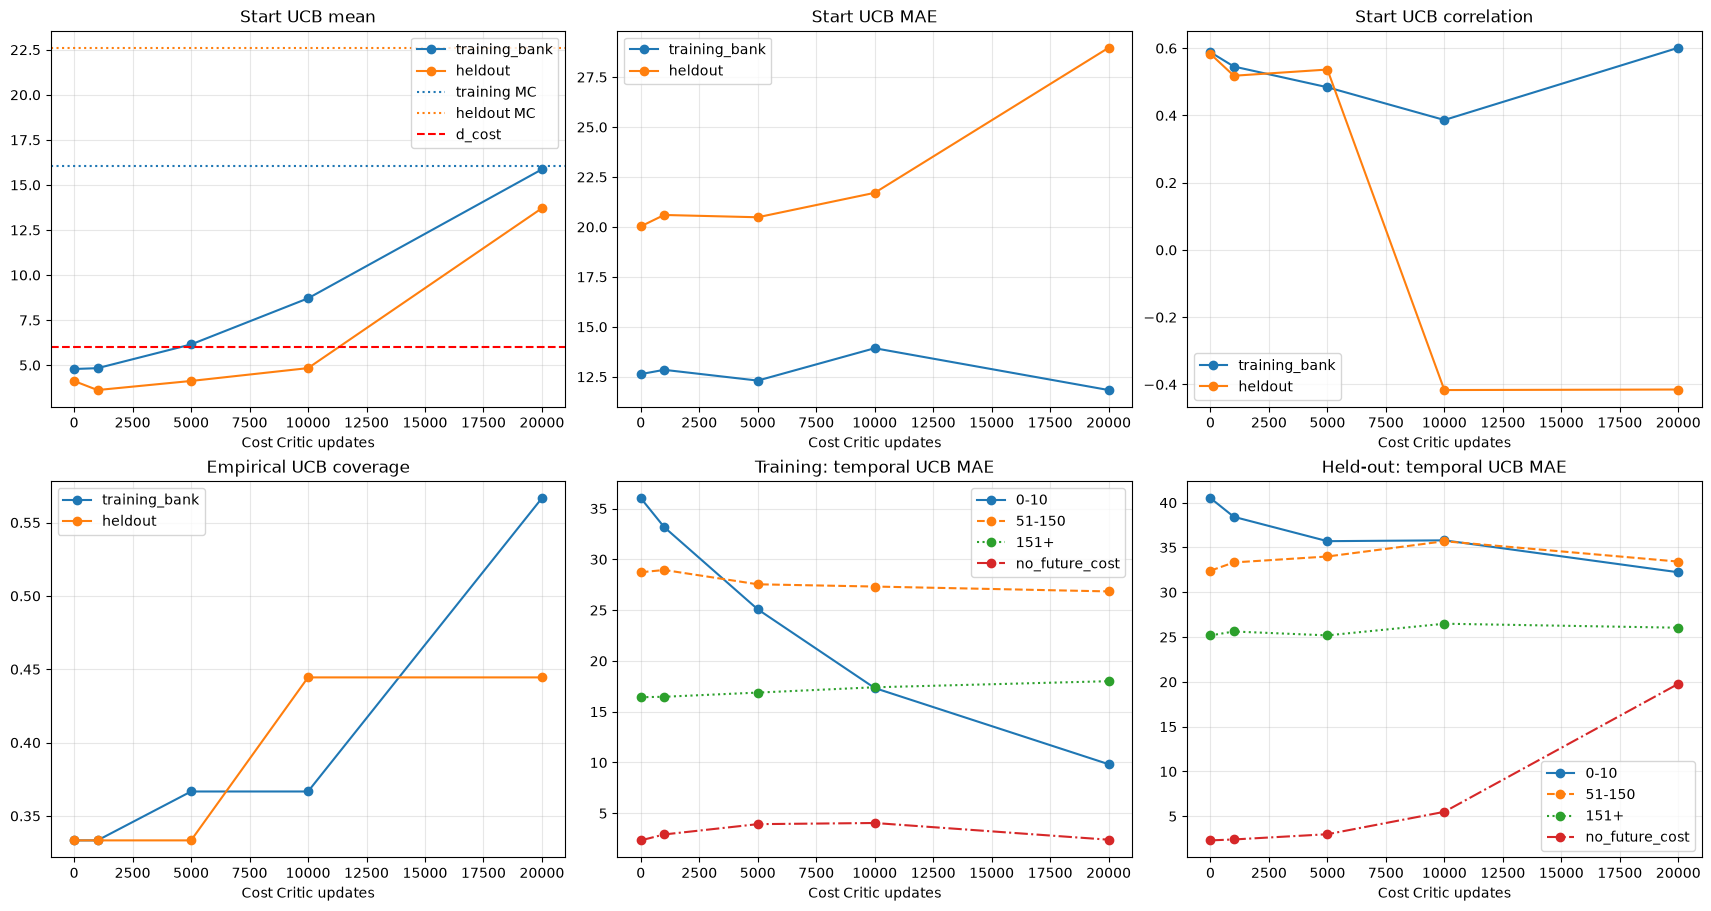

{'checkpoint_sha256': '1a21a7a182e32ec33524500d227c6784d61d7860d0884d7f81d2cd2aee15eea2',
 'cost_critic_updates': 20000,
 'training_scenario_level': {'count': 30,
  'mc_mean': 16.06304032750572,
  'q_mean': 13.464474577705065,
  'q_ucb_mean': 15.865923790136973,
  'mean_bias': -2.5985657498006556,
  'ucb_bias': -0.1971165373687477,
  'ucb_mae': 11.836039635619235,
  'ucb_rmse': 21.819103799723237,
  'ucb_correlation': 0.6011419270292627,
  'empirical_ucb_coverage': 0.5666666666666667},
 'heldout_scenario_level': {'count': 9,
  'mc_mean': 22.60962409476044,
  'q_mean': 10.843216940208716,
  'q_ucb_mean': 13.709339486228094,
  'mean_bias': -11.766407154551727,
  'ucb_bias': -8.90028460853235,
  'ucb_mae': 28.967372282935816,
  'ucb_rmse': 36.9033715553644,
  'ucb_correlation': -0.4150523638843732,
  'empirical_ucb_coverage': 0.4444444444444444},
 'interpretation_rules': {'training_good_heldout_bad': 'scenario coverage / overfitting / generalization problem',
  'training_bad_heldout_bad':

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_generalization_check/training_vs_heldout_calibration.png
All outputs: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_generalization_check


In [8]:
def summary_for(split, milestone):
    return next(x for x in summaries if x['split'] == split and x['milestone'] == milestone)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
for split, color in (('training_bank', 'tab:blue'), ('heldout', 'tab:orange')):
    values = [summary_for(split, m)['scenario_level'] for m in MILESTONES]
    axes[0,0].plot(MILESTONES, [x['q_ucb_mean'] for x in values], marker='o', color=color, label=split)
    axes[0,1].plot(MILESTONES, [x['ucb_mae'] for x in values], marker='o', color=color, label=split)
    axes[0,2].plot(MILESTONES, [np.nan if x['ucb_correlation'] is None else x['ucb_correlation'] for x in values], marker='o', color=color, label=split)
    axes[1,0].plot(MILESTONES, [x['empirical_ucb_coverage'] for x in values], marker='o', color=color, label=split)
    for lead, style in (('0-10','-'), ('51-150','--'), ('151+',':'), ('no_future_cost','-.')):
        temporal = [summary_for(split, m)['temporal_by_lead_bin'].get(lead) for m in MILESTONES]
        if all(x is not None for x in temporal):
            axes[1,1 if split == 'training_bank' else 2].plot(MILESTONES, [x['ucb_mae'] for x in temporal], linestyle=style, marker='o', label=lead)

training_mc = summary_for('training_bank', 0)['scenario_level']['mc_mean']
heldout_mc = summary_for('heldout', 0)['scenario_level']['mc_mean']
axes[0,0].axhline(training_mc, color='tab:blue', linestyle=':', label='training MC')
axes[0,0].axhline(heldout_mc, color='tab:orange', linestyle=':', label='heldout MC')
axes[0,0].axhline(config.learning.d_cost, color='red', linestyle='--', label='d_cost')
titles = [
    'Start UCB mean', 'Start UCB MAE', 'Start UCB correlation',
    'Empirical UCB coverage', 'Training: temporal UCB MAE', 'Held-out: temporal UCB MAE',
]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title); ax.set_xlabel('Cost Critic updates'); ax.grid(alpha=0.3); ax.legend()
figure_path = OUTPUT_RUN / 'training_vs_heldout_calibration.png'
fig.savefig(figure_path, dpi=170)
plt.show()

final = {split: summary_for(split, 20_000) for split in ('training_bank', 'heldout')}
diagnostic = {
    'checkpoint_sha256': CHECKPOINT_SHA256,
    'cost_critic_updates': 20_000,
    'training_scenario_level': final['training_bank']['scenario_level'],
    'heldout_scenario_level': final['heldout']['scenario_level'],
    'interpretation_rules': {
        'training_good_heldout_bad': 'scenario coverage / overfitting / generalization problem',
        'training_bad_heldout_bad': 'not explained by held-out distribution shift; inspect TD target, long-horizon propagation, and representation',
        'near_event_good_start_bad': 'long-horizon propagation shortage; test n-step or start-state MC auxiliary',
    },
}
(OUTPUT_RUN / 'final_diagnostic.json').write_text(json.dumps(diagnostic, ensure_ascii=False, indent=2), encoding='utf-8')
display(diagnostic)
print('Saved:', figure_path)
print('All outputs:', OUTPUT_RUN)

## 読み方

- **Training-bankでは高相関・低MAE、Held-outだけ悪い**: 小さいscenario bankへの過適合または汎化不足
- **両方悪い**: 同じscenario分布でも1-step TDの長期伝播、Bellman target、表現が不十分
- **0–50 step前は良いがStart/151+だけ悪い**: 長期伝播不足が主因
- **no-future-costが高い**: Cost表現が危険状態と安全状態を識別できず、値が漏れている

このNotebookは診断のみです。Cost定義、`d_cost=6`、Actor、CAL、1-step TDは変更しません。